In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import style
style.use('dark_background')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [2]:
# Load the wine dataset
wine = datasets.load_wine()

# print the names of the features
print(wine.feature_names)

['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


In [3]:
# print the label species(class_0, class_1, class_2)
print("Wine Target Names:", wine.target_names)

# Print the number of data samples, and features
print("Dataset Size:", wine.data.shape)

# print the wine labels (0:Class_0, 1:Class_1, 2:Class_3)
print("Dataset Labels:", wine.target)

Wine Target Names: ['class_0' 'class_1' 'class_2']
Dataset Size: (178, 13)
Dataset Labels: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]


In [4]:
#Prepare the data by splitting the features from the labels
x = wine.data
y = wine.target

# Standardize the features by removing the mean and scaling to unit variance
sc = StandardScaler()
x_scaled = sc.fit_transform(x)

In [5]:
# Apply PCA on the features
pca = PCA()
x_pca = pca.fit_transform(x_scaled)

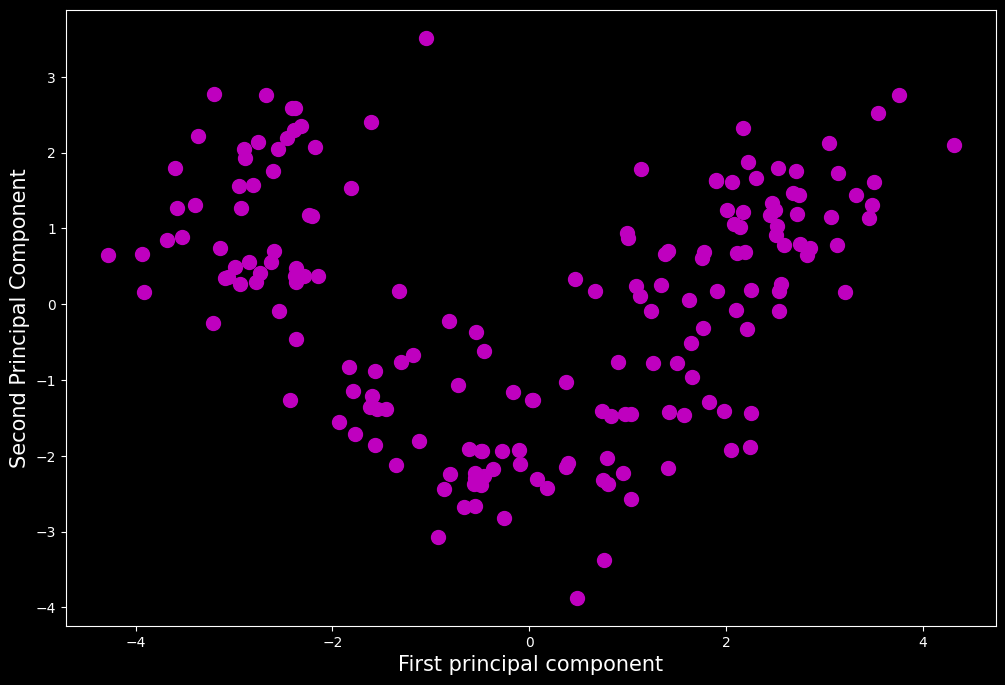

In [6]:
# Plot the Principal Components
plt.figure(figsize = (12,8))
plt.scatter(x_pca[:, 0], x_pca[:, 1], s = 100, c = 'm', label = 'alcohol')
plt.xlabel('First principal component', fontsize = 15)
plt.ylabel('Second Principal Component', fontsize = 15)
plt.show()

In [7]:
# Explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_
total_explained_variance_ratio = explained_variance_ratio.sum()

# Print results
print(f"\nExplained Variance Ratio:\n{explained_variance_ratio}")
print(f"Total Explained Variance Ratio: {total_explained_variance_ratio:.4f}")


Explained Variance Ratio:
[0.36198848 0.1920749  0.11123631 0.0706903  0.06563294 0.04935823
 0.04238679 0.02680749 0.02222153 0.01930019 0.01736836 0.01298233
 0.00795215]
Total Explained Variance Ratio: 1.0000


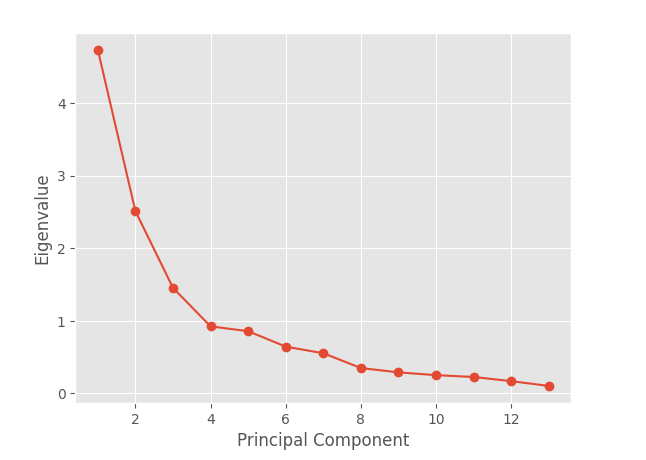

In [8]:
plt.style.use("ggplot")
y_values = pca.explained_variance_
x_values = range(1,len(y_values)+1)

plt.plot(x_values, y_values, marker='o')
plt.xlabel("Principal Component")
plt.ylabel("Eigenvalue")
plt.title("Scree Plot")
plt.title('Cumulative Explained Variance Ratio by Principal Components')
plt.show()

In [9]:
# Optimal number of principal components to retain, balancing the goal of dimensionality reduction with preserving a sufficient amount of information from the original dataset
pca = PCA(n_components=4)
x_pca = pca.fit_transform(x_scaled)

# Explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_
total_explained_variance_ratio = explained_variance_ratio.sum()

# Print results
print(f"\nExplained Variance Ratio:\n{explained_variance_ratio}")
print(f"Total Explained Variance Ratio: {total_explained_variance_ratio:.4f}")


Explained Variance Ratio:
[0.36198848 0.1920749  0.11123631 0.0706903 ]
Total Explained Variance Ratio: 0.7360


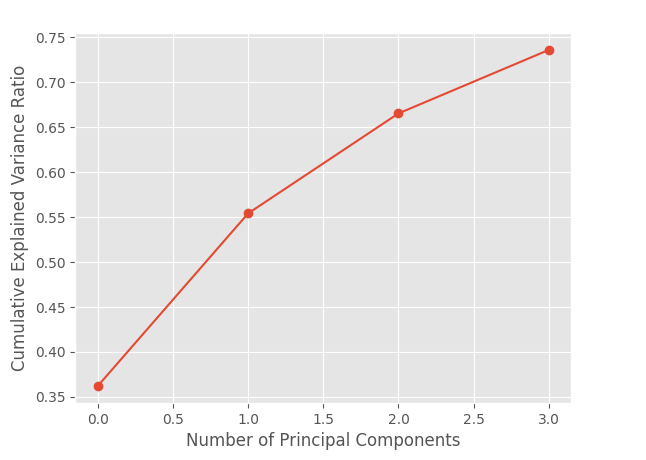

In [10]:
# Plot explained variance ratio
cumulative_variance_ratio = np.cumsum(explained_variance_ratio)
plt.plot(cumulative_variance_ratio, marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.title('Cumulative Explained Variance Ratio by Principal Components')
plt.show()

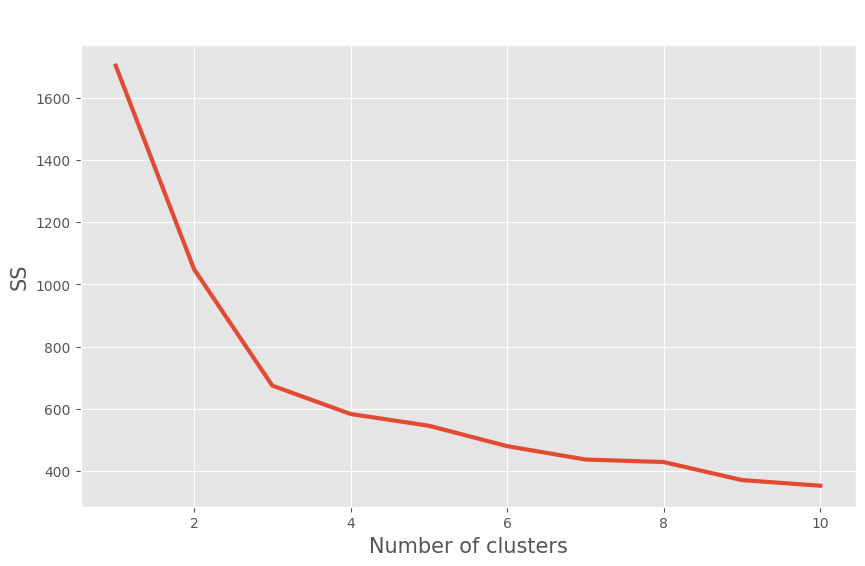

In [11]:
# Apply Elbow Method to determine optimal k
ss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
    kmeans.fit(x_pca)
    ss.append(kmeans.inertia_) # kmeans.inertia_ will give us wcss value
plt.figure(figsize = (10,6))
plt.plot(range(1, 11), ss, lw = 3)
plt.title('The Elbow Method', fontsize = 25)
plt.xlabel('Number of clusters', fontsize = 15)
plt.ylabel('SS', fontsize =15 )
plt.show()

In [12]:
# Apply Clustering with optimal number of clusters
kmeans = KMeans(n_clusters = 3, init = 'k-means++', random_state = 42)
y_pred = kmeans.fit_predict(x_pca)

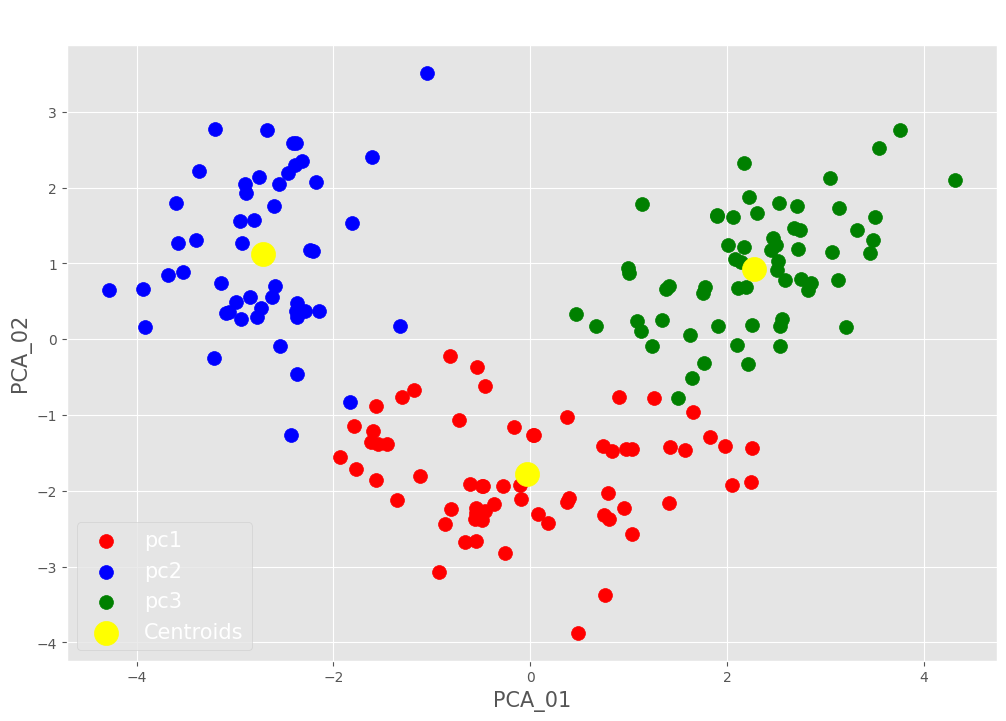

In [13]:
# Plot Clustering
pca = PCA(n_components = 2)
x_2d = pca.fit_transform(x_scaled)

plt.figure(figsize = (12,8))
plt.scatter(x_2d[y_pred == 0, 0], x_2d[y_pred == 0, 1], s = 100, c = 'red', label = 'pc1')
plt.scatter(x_2d[y_pred == 1, 0], x_2d[y_pred == 1, 1], s = 100, c = 'blue', label = 'pc2')
plt.scatter(x_2d[y_pred == 2, 0], x_2d[y_pred == 2, 1], s = 100, c = 'green', label = 'pc3')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s = 300, c = 'yellow', label = 'Centroids')
plt.title('Wine Dataset Clustering', fontsize = 25)
plt.xlabel('PCA_01', fontsize = 15)
plt.ylabel('PCA_02', fontsize = 15)
plt.legend(fontsize = 15)
plt.show()